# Part 1 — Data Collection & the Point-in-Time Dataset

**Project:** Cross-sectional machine-learning factor *ranking* for the S&P 500.

Before any factor or model, we need a dataset we can trust. This notebook documents how the
raw data is assembled and, critically, how two biases that quietly inflate most backtests are
controlled:

1. **Survivorship bias** — studying only stocks that are in the index *today*.
2. **Look-ahead bias** — using a fundamental before it was actually published.

**Data source:** Financial Modeling Prep (FMP) *stable* API. **Universe:** point-in-time S&P 500.
**Window:** monthly, 2000-01 to 2026-04.

> All heavy lifting lives in the importable `qfr` package (`src/qfr/`); this notebook is the
> narrative on top of it.

In [1]:
import pandas as pd
from IPython.display import Image
from qfr.utils.config import settings, PROJECT_ROOT

P = settings.processed_dir
CHARTS = PROJECT_ROOT / 'charts'

master = pd.read_parquet(P / 'master_pit.parquet')
universe = pd.read_parquet(P / 'universe_panel.parquet')
members_now = pd.read_parquet(P / 'members_now.parquet')

print(f'master_pit : {master.shape[0]:,} member-months x {master.shape[1]} columns')
print(f'date range : {master.date.min().date()}  ->  {master.date.max().date()}')
print(f'current S&P 500 members : {len(members_now)}')
print(f'unique symbols ever in-universe : {universe.symbol.nunique()}')
master.head()

master_pit : 158,243 member-months x 61 columns
date range : 2000-01-31  ->  2026-04-30
current S&P 500 members : 503
unique symbols ever in-universe : 1088


,date,symbol,adjClose,ret_fwd_1m,ret_fwd_3m,ret_fwd_6m,fiscalYear,period,acceptedDate,period_end,...,revenueGrowth,epsgrowth,netIncomeGrowth,ebitdaGrowth,filing_lag_days,sector,has_price,has_fundamentals,fresh_filing,investable
0,2000-01-31,AA,54.34000,-0.013434,-0.065513,-0.124954,NaN,NaN,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,Basic Materials,True,False,False,False
1,2000-01-31,AAPL,0.77655,0.101114,0.198262,-0.020475,1999,Q4,1999-12-22,1999-09-25,...,-0.142490,-0.515873,-0.453202,0.211382,40.0,Technology,True,True,True,True
2,2000-01-31,ABI,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,Financial Services,False,False,False,False
3,2000-01-31,ABS,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,Unknown,False,False,False,False
4,2000-01-31,ABT,8.07000,0.013631,0.185874,0.291202,1999,Q3,1999-11-08,1999-09-30,...,-0.037773,-0.285714,-0.274296,-0.233882,84.0,Healthcare,True,True,True,True


## 1. The universe is point-in-time (survivorship-bias-free)

**What:** at every month-end we reconstruct *which stocks were actually in the S&P 500 on that
date*, by starting from today's members and walking FMP's historical change-log backwards.

**Why it matters:** a study that uses *today's* 500 names silently deletes every company that was
dropped after a crash, acquisition or bankruptcy — exactly the losers. That inflates returns. We
keep them: **1,088 distinct names** pass through the universe over 2000–2026, versus ~500 today.

In [2]:
rows = []
for y in range(2000, 2027):
    d = pd.Timestamp(f'{y}-12-31') if y < 2026 else pd.Timestamp('2026-04-30')
    sub = universe[universe.date == universe.loc[universe.date <= d, 'date'].max()]
    rows.append({'as_of': d.date(), 'members': sub.symbol.nunique()})
pd.DataFrame(rows).set_index('as_of').T

as_of,2000-12-31,2001-12-31,2002-12-31,2003-12-31,2004-12-31,2005-12-31,2006-12-31,2007-12-31,2008-12-31,2009-12-31,...,2017-12-31,2018-12-31,2019-12-31,2020-12-31,2021-12-31,2022-12-31,2023-12-31,2024-12-31,2025-12-31,2026-04-30
members,494,495,495,496,497,499,499,499,500,500,...,504,505,505,505,505,504,504,504,503,503


The count sits at ~492–505 across the whole sample — correct, because the index itself ran a few
names short of 500 in the early 2000s. The chart below shows the point-in-time membership (navy)
against the names for which we have complete data (red); the grey wedge is the early-period data
gap discussed in §4.

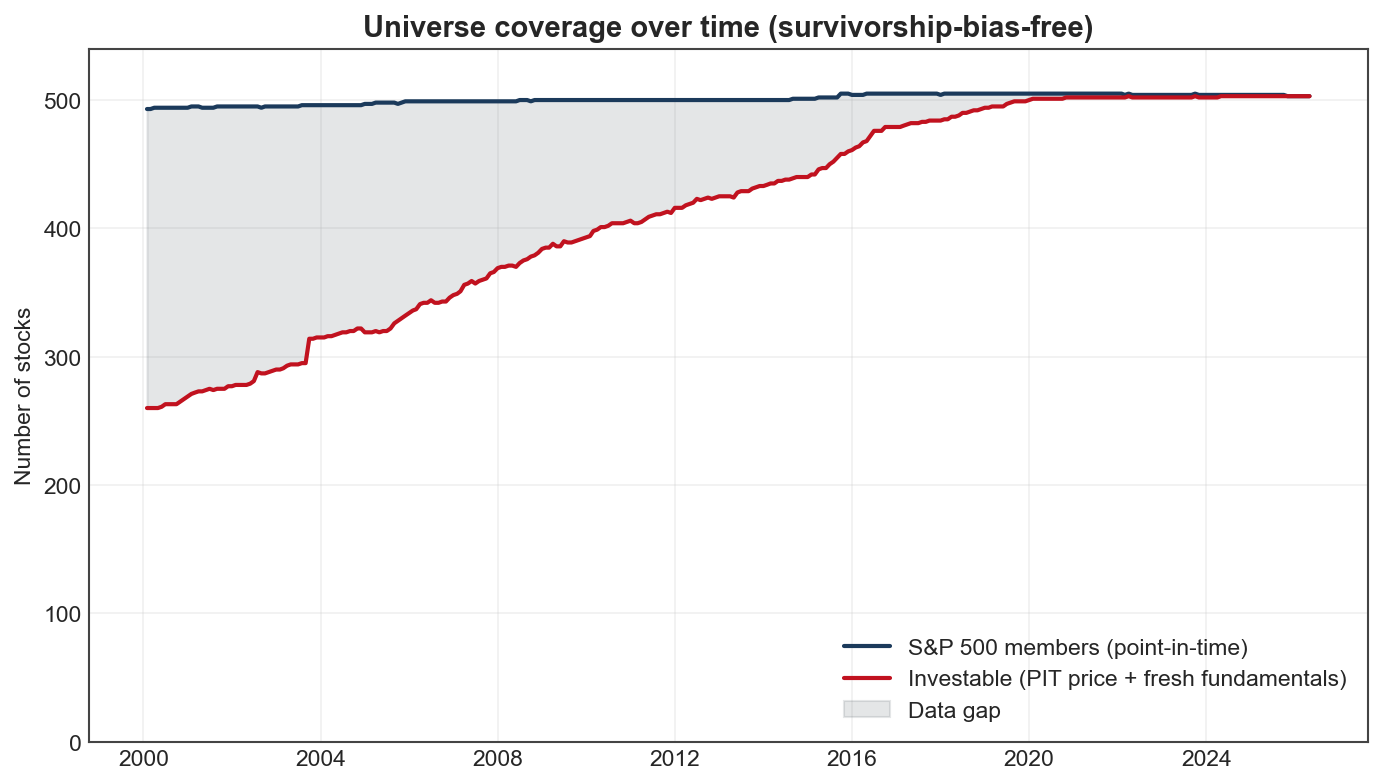

In [3]:
Image(filename=str(CHARTS / '01_universe_coverage.png'))

### How much survivorship bias does this remove?
The line below is the share of each month's *actual* index that is **no longer** in today's S&P
500. In 2000 that's ~60% — a naïve 'current constituents' study would be blind to six of every ten
stocks that genuinely made up the index. It falls to 0% today by construction.

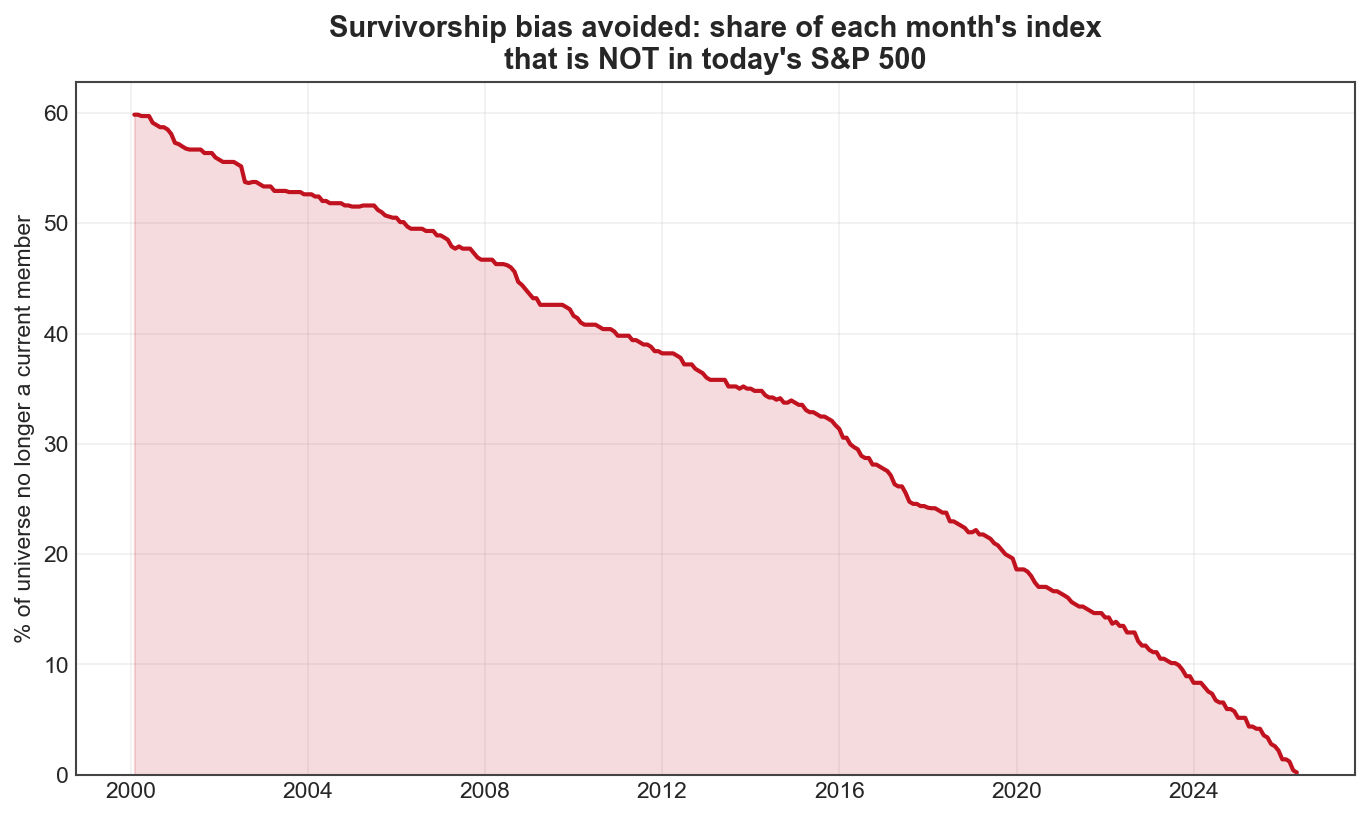

In [4]:
Image(filename=str(CHARTS / '01_survivorship_bias.png'))

## 2. No look-ahead: fundamentals are lagged to their filing date

**What:** a fundamental is only usable on a rebalance date once its SEC filing was *publicly
accepted* (`acceptedDate`). For each date we take the most recent filing with
`acceptedDate <= rebalance date`.

**Why it matters:** quarter-end is the *period* date, but the 10-Q isn't filed until ~30–90 days
later. Using period-end data on period-end dates would let the model 'see' earnings before they
were public — a classic, silent source of fake alpha.

The cell below verifies the control holds for **every** investable observation.

In [5]:
inv = master[master.investable]
violations = int((inv.acceptedDate > inv.date).sum())
med = inv.filing_lag_days.median()
p95 = inv.filing_lag_days.quantile(0.95)
print(f'investable member-months : {len(inv):,}')
print(f'LOOK-AHEAD violations    : {violations}   (acceptedDate after the rebalance date)')
print(f'filing lag (days): median {med:.0f} | p95 {p95:.0f} | max {inv.filing_lag_days.max():.0f}')

print('\nAAPL - fundamentals only change AFTER each acceptedDate:')
inv[inv.symbol == 'AAPL'][['date','acceptedDate','period_end','eps',
                           'priceToEarningsRatio']].tail(6)

investable member-months : 130,817
LOOK-AHEAD violations    : 0   (acceptedDate after the rebalance date)
filing lag (days): median 49 | p95 93 | max 399

AAPL - fundamentals only change AFTER each acceptedDate:


,date,acceptedDate,period_end,eps,priceToEarningsRatio
155226,2025-11-30,2025-10-31 06:01:26,2025-09-27,1.85,34.758827
155729,2025-12-31,2025-10-31 06:01:26,2025-09-27,1.85,34.758827
156232,2026-01-31,2026-01-30 06:01:32,2025-12-27,2.85,23.945569
156735,2026-02-28,2026-01-30 06:01:32,2025-12-27,2.85,23.945569
157238,2026-03-31,2026-01-30 06:01:32,2025-12-27,2.85,23.945569
157741,2026-04-30,2026-01-30 06:01:32,2025-12-27,2.85,23.945569


Zero violations. The lag distribution below is positive everywhere (median ~49 days); its
multi-modal shape is the interaction of *monthly* rebalances with *quarterly* filings.

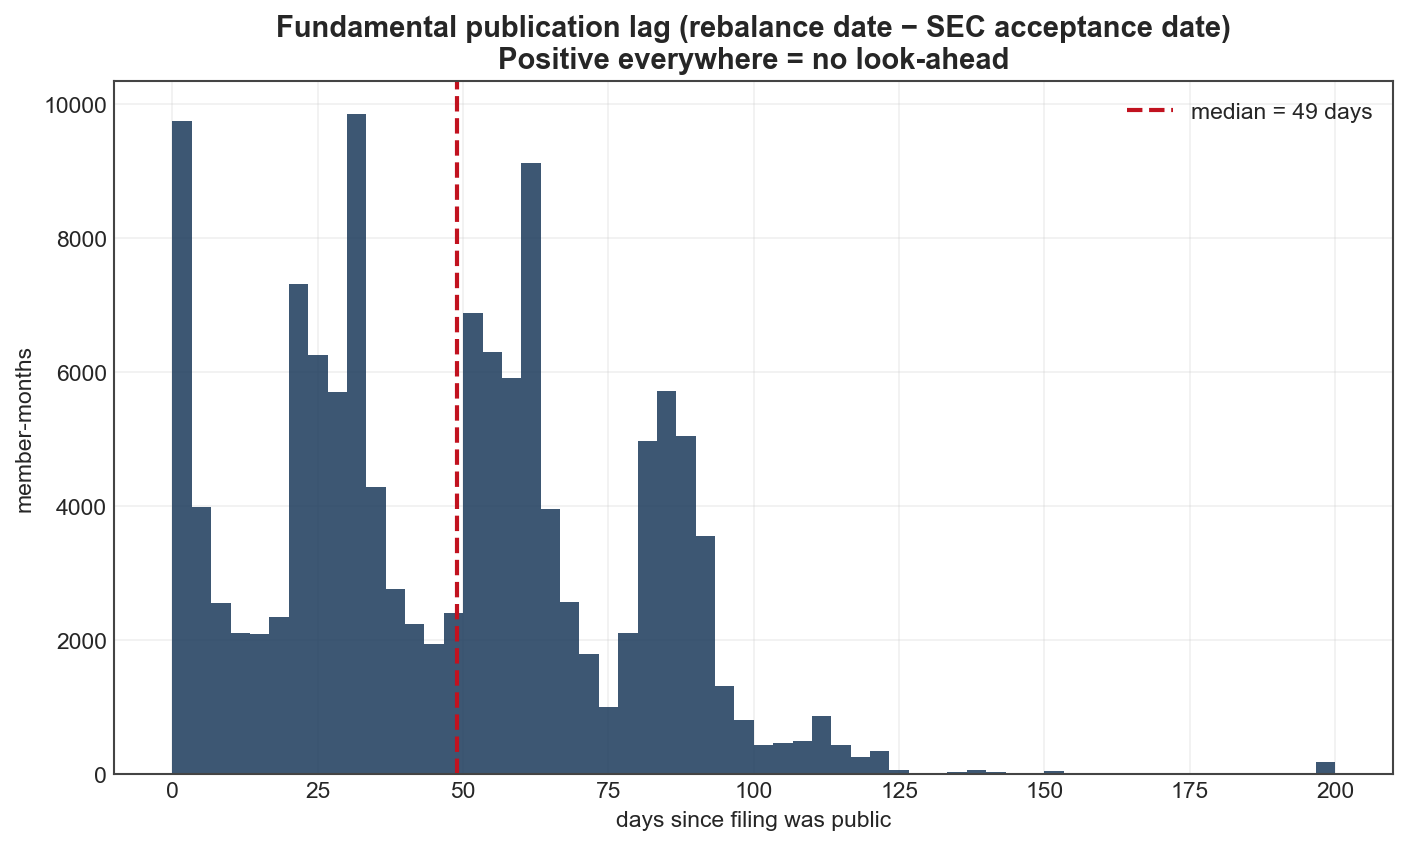

In [6]:
Image(filename=str(CHARTS / '01_filing_lag_hist.png'))

## 3. Prices and the prediction target

Prices are split- and dividend-adjusted (`adjClose`). The labels are **forward** total returns
over 1, 3 and 6 months. We will not predict their exact value — we predict their *cross-sectional
ranking*. The histogram shows the monthly spread that a ranking model tries to exploit.

In [7]:
inv[['ret_fwd_1m','ret_fwd_3m','ret_fwd_6m']].describe(
    percentiles=[0.05, 0.5, 0.95]).round(4)

,ret_fwd_1m,ret_fwd_3m,ret_fwd_6m
count,130263.0000,129137.0000,127451.0000
mean,0.0104,0.0311,0.0628
std,0.1000,0.1800,0.2623
min,-0.9984,-0.9993,-0.9996
5%,-0.1324,-0.2159,-0.2904
50%,0.0106,0.0300,0.0557
95%,0.1504,0.2727,0.4205
max,6.0582,14.5403,16.5326


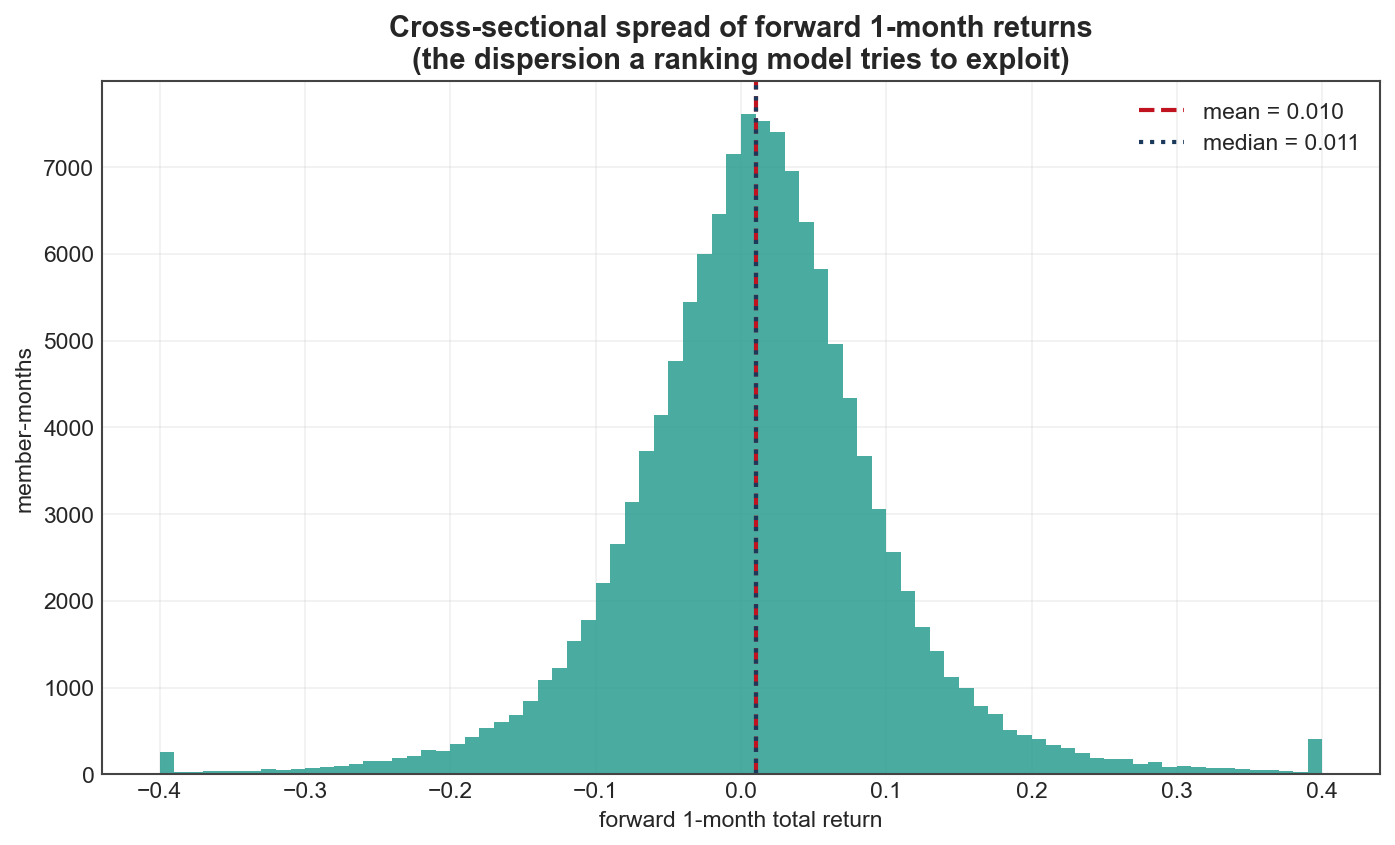

In [8]:
Image(filename=str(CHARTS / '01_forward_return_dist.png'))

## 4. Data coverage & quality (the honest part)

Not every member-month is usable: we require a point-in-time price **and** a fresh fundamental
filing. Coverage is near-complete recently but thinner pre-2005, because more early-2000s names
later delisted and vendor history for them is sparser. We flag this rather than hide it — the
`investable` column gates everything downstream.

In [9]:
by_year = (master.assign(year=master.date.dt.year)
                 .groupby('year')[['has_price','has_fundamentals','investable']]
                 .mean().round(3))
by_year

,has_price,has_fundamentals,investable
year,,,
2000,0.539,0.584,0.532
2001,0.561,0.612,0.554
2002,0.579,0.643,0.573
2003,0.620,0.671,0.606
2004,0.672,0.686,0.642
2005,0.680,0.697,0.651
2006,0.709,0.732,0.686
2007,0.742,0.770,0.720
2008,0.774,0.798,0.750


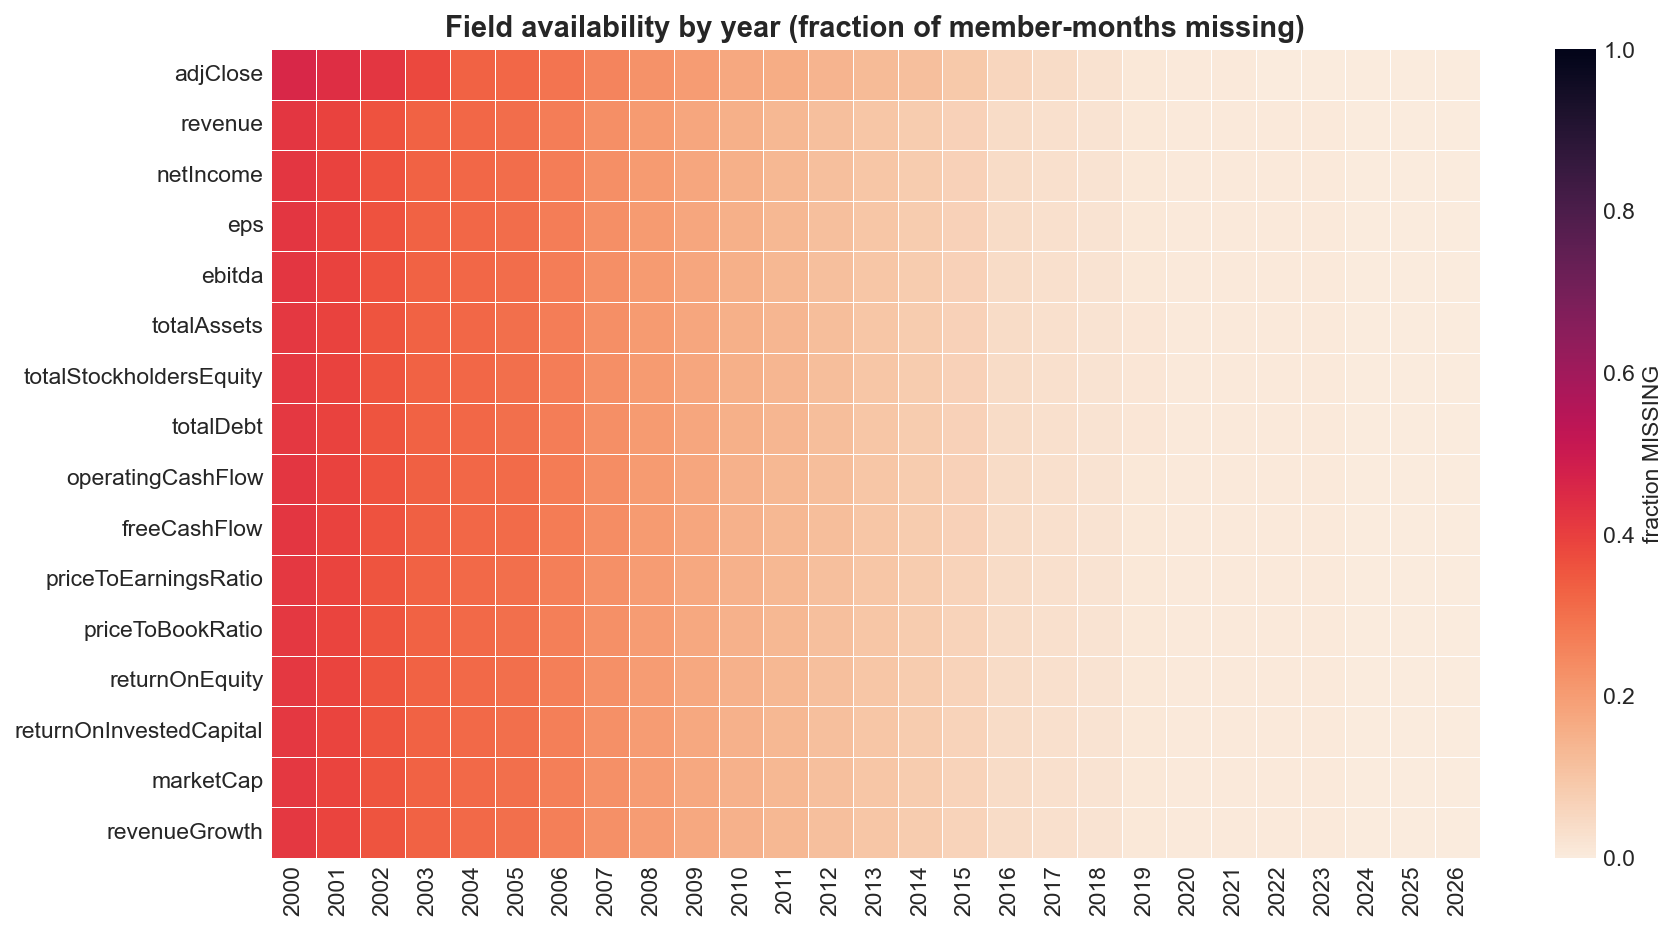

In [10]:
Image(filename=str(CHARTS / '01_missing_data_heatmap.png'))

## 5. Raw signal correlations

A first look at redundancy among the raw vendor metrics: valuation ratios cluster together, the
profitability/return metrics cluster, and margins cluster. This motivates the deliberate factor
selection and orthogonalisation in Parts 3–4.

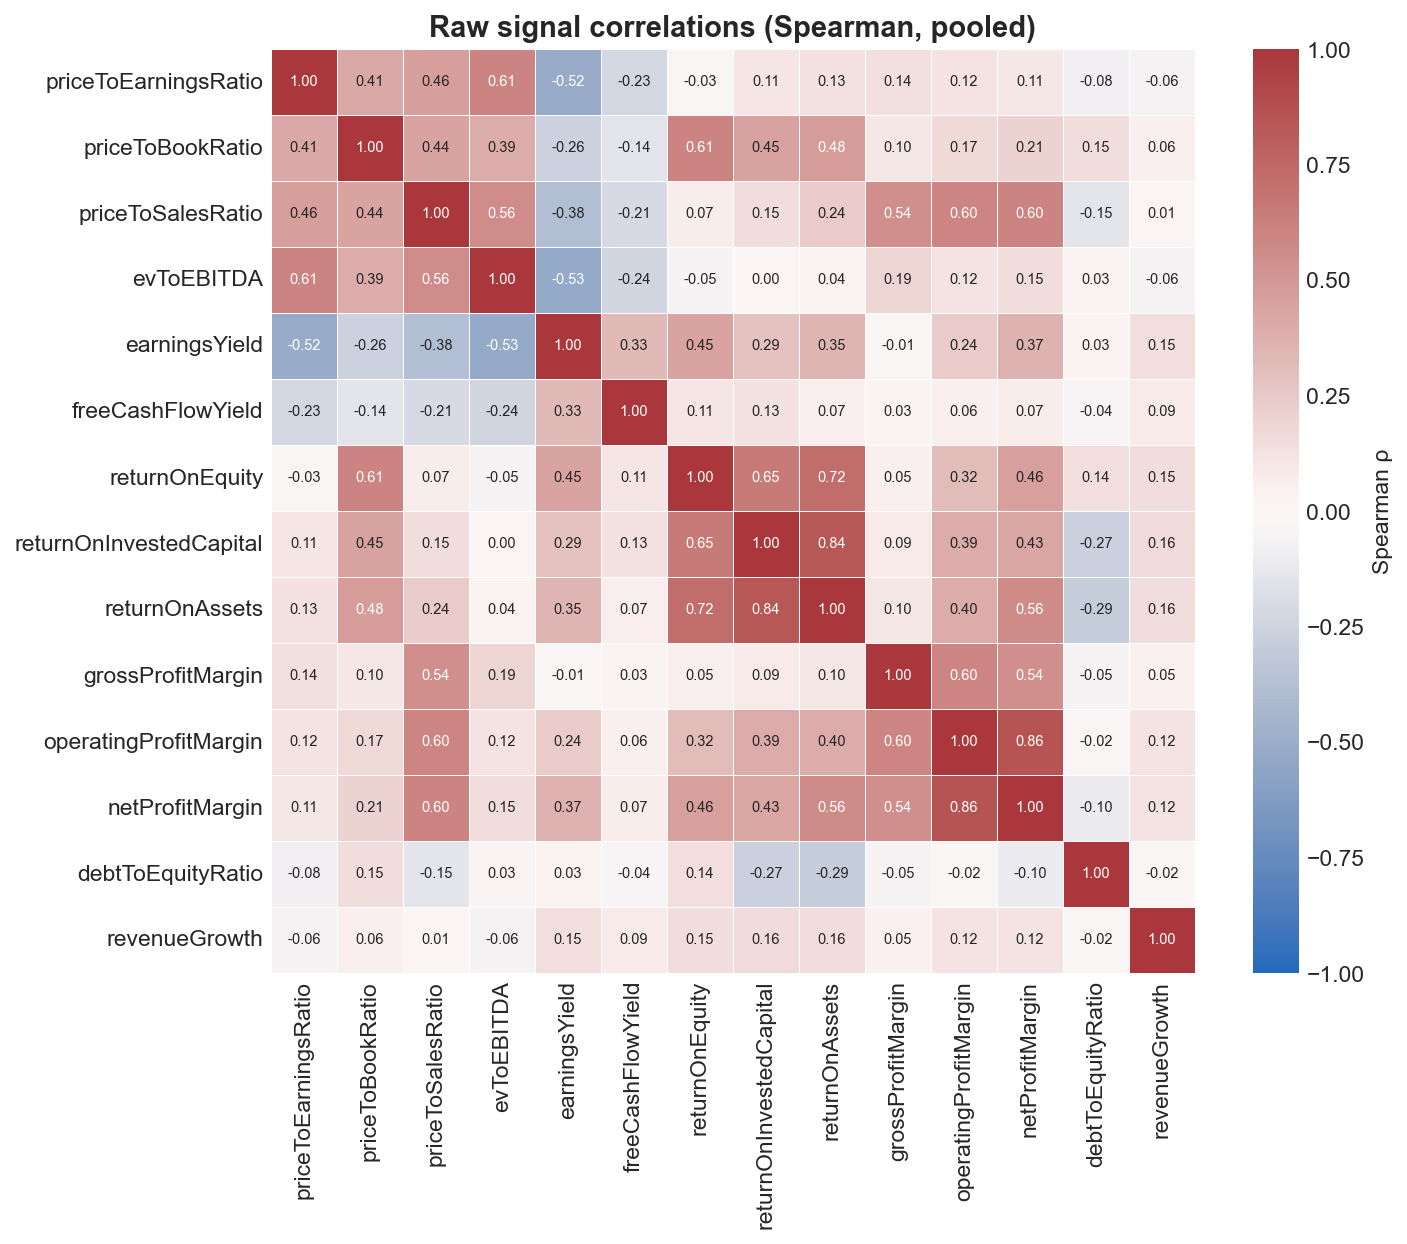

In [11]:
Image(filename=str(CHARTS / '01_factor_correlation.png'))

## Summary statistics

In [12]:
pd.read_csv(CHARTS / '01_summary_stats.csv', index_col=0).round(3)

,count,mean,std,min,5%,25%,50%,75%,95%,max
ret_fwd_1m,130263.0,1.000000e-02,1.000000e-01,-0.998,-1.320000e-01,-3.900000e-02,1.100000e-02,5.800000e-02,1.500000e-01,6.058000e+00
ret_fwd_3m,129137.0,3.100000e-02,1.800000e-01,-0.999,-2.160000e-01,-5.600000e-02,3.000000e-02,1.140000e-01,2.730000e-01,1.454000e+01
ret_fwd_6m,127451.0,6.300000e-02,2.620000e-01,-1.000,-2.900000e-01,-6.600000e-02,5.600000e-02,1.760000e-01,4.210000e-01,1.653300e+01
priceToEarningsRatio,130817.0,2.018500e+01,7.866610e+02,-88655.245,-1.203100e+01,1.061300e+01,1.713900e+01,2.676500e+01,6.913300e+01,7.563527e+04
priceToBookRatio,130817.0,7.852900e+01,1.561823e+04,-13463.406,5.330000e-01,1.539000e+00,2.671000e+00,4.932000e+00,1.517100e+01,3.261300e+06
returnOnEquity,130817.0,1.283000e+00,2.601020e+02,-100.722,-6.400000e-02,1.900000e-02,3.800000e-02,6.300000e-02,1.660000e-01,5.431400e+04
marketCap,130817.0,4.748779e+10,1.469583e+11,0.000,2.975951e+09,8.930025e+09,1.729029e+10,3.923998e+10,1.684228e+11,4.658377e+12
revenueGrowth,130817.0,5.680000e-01,5.872500e+01,-27.457,-2.070000e-01,-3.400000e-02,1.700000e-02,7.300000e-02,2.800000e-01,9.927000e+03
filing_lag_days,130817.0,4.775800e+01,3.078500e+01,0.000,2.000000e+00,2.500000e+01,4.900000e+01,6.700000e+01,9.300000e+01,3.990000e+02


## Limitations & what's next

- **Early-period coverage** (~260 names/month in 2000 vs ~500 now) — results pre-2005 lean on a
  smaller cross-section.
- **Ticker recycling** (e.g. `CA`) — handled by requiring price/fundamental overlap; a few names
  are still dropped.
- **Vendor-computed ratios** are carried for convenience but Part 3 rebuilds key value factors
  from raw line items + point-in-time price, for full transparency.

**Next — Part 2 (EDA):** distributions, skew, outliers and rolling behaviour of the raw inputs
before we engineer factors.